# Task 1 (Beginner) — Boston House Price Prediction
**ShadowFox AIML Internship**

**Problem statement:** Using the provided dataset containing features such as number of rooms, crime rates, and other relevant factors, design and implement a regression model to accurately predict Boston house prices. The solution involves *data preprocessing, model selection, training,* and *evaluation*.

## 1. Setup — importing the toolkit

Every ML project starts the same way: import your libraries.

| Library | Job it does for us |
|---|---|
| `pandas` / `numpy` | load tables, crunch numbers |
| `matplotlib` / `seaborn` | draw charts (EDA) |
| `scikit-learn` | models, metrics, splitting data |
| `joblib` | save the trained model to a file |

In [1]:
# --- data handling ---
import numpy as np
import pandas as pd

# --- charts ---
import matplotlib.pyplot as plt
import seaborn as sns

# --- machine learning ---
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# --- saving the model ---
import joblib

# cosmetic settings
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)
pd.set_option("display.float_format", "{:.2f}".format)

print("Libraries loaded ✔")

Libraries loaded ✔


## 2. Loading the dataset

The dataset is the classic **Boston Housing dataset** (506 suburbs of Boston, collected in 1978).
Each row = one suburb. Each column = a factor about that suburb.

| Column | Meaning |
|---|---|
| `crim` | per-capita crime rate |
| `zn` | % of land zoned for large residential lots |
| `indus` | % of non-retail business acres |
| `chas` | 1 if the suburb borders the Charles river, else 0 |
| `nox` | air pollution (nitric-oxide concentration) |
| `rm` | **average number of rooms per house** |
| `age` | % of houses built before 1940 |
| `dis` | distance to Boston job centres |
| `rad` | accessibility to radial highways |
| `tax` | property-tax rate |
| `ptratio` | pupil–teacher ratio (school crowding) |
| `b` | historical demographic index |
| `lstat` | **% of lower-income population** |
| `medv` | ⭐ **median house value (in $1000s) — the price we must predict** |

> In ML language: the columns we predict **from** are *features (X)*, and the column we predict **is the target (y)** — here `medv`.

In [2]:
df = pd.read_csv("boston_housing.csv")

print("Rows (suburbs):", df.shape[0], "| Columns:", df.shape[1])
df.head()

Rows (suburbs): 506 | Columns: 14


,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
0,0.01,18.00,2.31,0,0.54,6.58,65.20,4.09,1,296,15.30,396.90,4.98,24.00
1,0.03,0.00,7.07,0,0.47,6.42,78.90,4.97,2,242,17.80,396.90,9.14,21.60
2,0.03,0.00,7.07,0,0.47,7.18,61.10,4.97,2,242,17.80,392.83,4.03,34.70
3,0.03,0.00,2.18,0,0.46,7.00,45.80,6.06,3,222,18.70,394.63,2.94,33.40
4,0.07,0.00,2.18,0,0.46,7.15,54.20,6.06,3,222,18.70,396.90,5.33,36.20


## 3. Data health check 🔍
Before modeling, we *always* ask three questions:
1. Are there **missing values**? (empty cells)
2. What are the **data types**? (numbers vs text)
3. Do the **ranges** look sane? (min/max/average)

In [3]:
print("Missing values per column:")
print(df.isnull().sum())
print("\nAny missing at all? ->", df.isnull().values.any())
df.describe()

Missing values per column:
crim       0
zn         0
indus      0
chas       0
nox        0
rm         0
age        0
dis        0
rad        0
tax        0
ptratio    0
b          0
lstat      0
medv       0
dtype: int64

Any missing at all? -> False


,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
count,506.00,506.00,506.00,506.00,506.00,506.00,506.00,506.00,506.00,506.00,506.00,506.00,506.00,506.00
mean,3.61,11.36,11.14,0.07,0.55,6.28,68.57,3.80,9.55,408.24,18.46,356.67,12.65,22.53
std,8.60,23.32,6.86,0.25,0.12,0.70,28.15,2.11,8.71,168.54,2.16,91.29,7.14,9.20
min,0.01,0.00,0.46,0.00,0.39,3.56,2.90,1.13,1.00,187.00,12.60,0.32,1.73,5.00
25%,0.08,0.00,5.19,0.00,0.45,5.89,45.02,2.10,4.00,279.00,17.40,375.38,6.95,17.02
50%,0.26,0.00,9.69,0.00,0.54,6.21,77.50,3.21,5.00,330.00,19.05,391.44,11.36,21.20
75%,3.68,12.50,18.10,0.00,0.62,6.62,94.07,5.19,24.00,666.00,20.20,396.23,16.96,25.00
max,88.98,100.00,27.74,1.00,0.87,8.78,100.00,12.13,24.00,711.00,22.00,396.90,37.97,50.00


**Reading the output:** `count` = 506 everywhere → no missing values. `mean`/`min`/`max` let us sanity-check
(e.g. `rm` runs from ~3.5 to ~8.8 rooms — plausible).

## 4. Exploratory Data Analysis (EDA)
We plot first, model second — charts reveal which features matter. Three things we look at:

1. **What does the target (`medv`) look like?** → histogram
2. **Which features correlate with price?** → correlation heatmap
3. **The two strongest relationships up close** → scatter plots

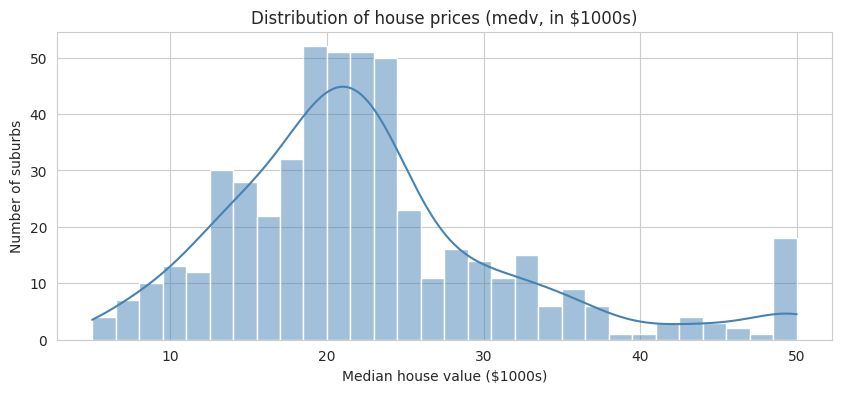

Notice the pile-up at 50 — prices were capped at $50k in this old survey. We will deal with this soon.


In [4]:
# 4.1 Distribution of house prices
plt.figure(figsize=(10, 4))
sns.histplot(df["medv"], kde=True, bins=30, color="steelblue")
plt.title("Distribution of house prices (medv, in $1000s)")
plt.xlabel("Median house value ($1000s)")
plt.ylabel("Number of suburbs")
plt.show()

print("Notice the pile-up at 50 — prices were capped at $50k in this old survey. We will deal with this soon.")

### 4.2 Correlation heatmap
**Correlation** measures how strongly two columns move together (from **-1** opposite to **+1** together).
We care most about the bottom row — correlation of every feature with `medv`.

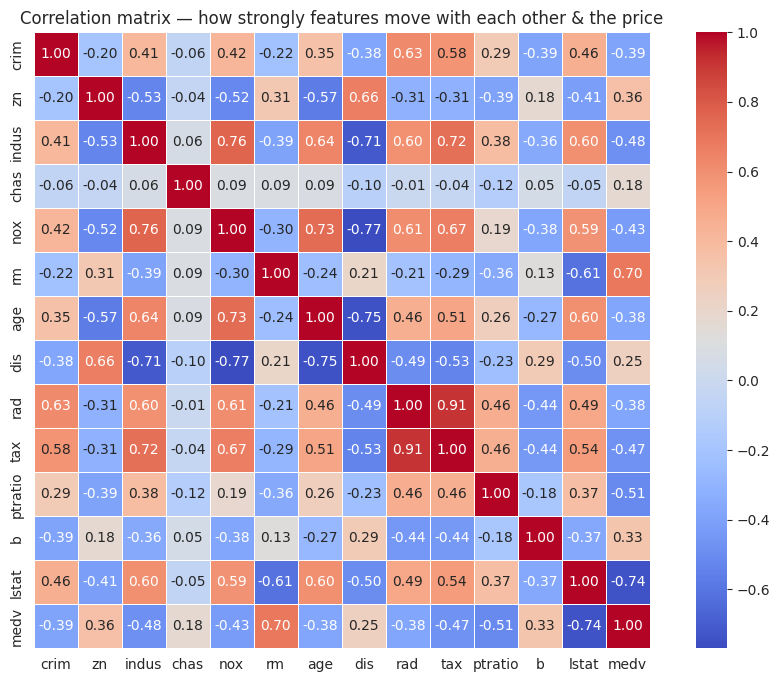

Top features positively related to price:
rm   0.70
zn   0.36
b    0.33
Name: medv, dtype: float64

Top features negatively related to price:
lstat     -0.74
ptratio   -0.51
indus     -0.48
Name: medv, dtype: float64


In [5]:
plt.figure(figsize=(12, 8))
corr = df.corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", square=True, linewidths=.5)
plt.title("Correlation matrix — how strongly features move with each other & the price")
plt.show()

print("Top features positively related to price:")
print(corr["medv"].sort_values(ascending=False).head(4)[1:])
print("\nTop features negatively related to price:")
print(corr["medv"].sort_values().head(3))

**Two clear winners:**
- `rm` (rooms): correlation ≈ **+0.70** → more rooms ⇒ higher price
- `lstat` (% lower-income): correlation ≈ **−0.74** → higher poverty ⇒ lower price

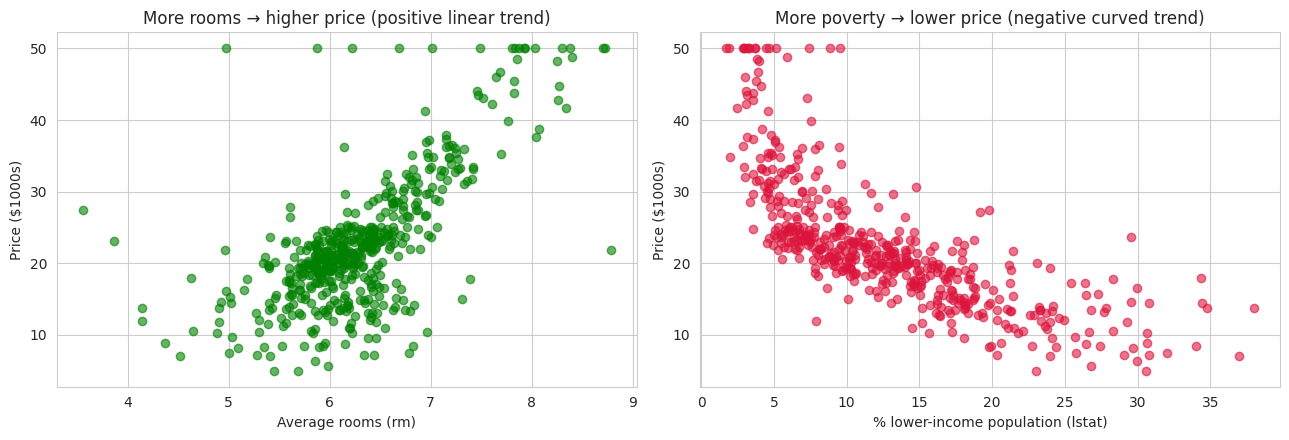

In [6]:
# 4.3 The two strongest drivers, up close
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].scatter(df["rm"], df["medv"], alpha=0.6, color="green")
axes[0].set_xlabel("Average rooms (rm)")
axes[0].set_ylabel("Price ($1000s)")
axes[0].set_title("More rooms → higher price (positive linear trend)")

axes[1].scatter(df["lstat"], df["medv"], alpha=0.6, color="crimson")
axes[1].set_xlabel("% lower-income population (lstat)")
axes[1].set_ylabel("Price ($1000s)")
axes[1].set_title("More poverty → lower price (negative curved trend)")

plt.tight_layout()
plt.show()

## 5. Data preprocessing — handling outliers with the IQR technique 📐
This is the exact method shown in the internship material:

$$\text{IQR} = Q3 - Q1$$
$$\text{Lower limit} = Q1 - 1.5 \times \text{IQR}, \qquad \text{Upper limit} = Q3 + 1.5 \times \text{IQR}$$

Any data point outside these limits is an **outlier** and is excluded.

**Why?** Outliers (e.g. 3 mansions priced 10× higher) drag a regression line toward them and hurt predictions for normal houses.

Additionally, the prices were **capped at $50k** in the original survey (the histogram pile-up). Those rows are not real prices, so we drop them too.

In [7]:
def iqr_limits(series):
    """Return (lower, upper) acceptable limits for a column using the 1.5*IQR rule."""
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return lower, upper

# Demonstrate the math on the 'medv' (price) column
lower, upper = iqr_limits(df["medv"])
print(f"For medv (price):  IQR limits = [{lower:.2f}, {upper:.2f}]  (in $1000s)")

# 1) Remove the survey-capped rows (medv == 50.0)
capped = (df["medv"] >= 50.0).sum()
df_clean = df[df["medv"] < 50.0].copy()

# 2) Remove price outliers outside the IQR limits
outlier_mask = (df_clean["medv"] < lower) | (df_clean["medv"] > upper)
outliers = outlier_mask.sum()
df_clean = df_clean[~outlier_mask]

print(f"Removed {capped} survey-capped rows and {outliers} IQR outliers.")
print(f"Clean dataset: {df_clean.shape[0]} suburbs (was {df.shape[0]})")

For medv (price):  IQR limits = [5.06, 36.96]  (in $1000s)
Removed 16 survey-capped rows and 24 IQR outliers.
Clean dataset: 466 suburbs (was 506)


## 6. Splitting the data — train vs test 🧪
**The golden rule of ML:** never test a model on the same data it studied.

- **Training set (80%)** — the model learns patterns from this
- **Test set (20%)** — kept hidden, used only at the end to measure real-world performance

`random_state=42` just fixes the shuffle so the result is reproducible (same split every run).
Scaling is unnecessary here — all our models handle raw units fine (trees don't need it; linear regression coefficients absorb the scale).

In [8]:
# X = features (everything except price), y = target (price)
X = df_clean.drop("medv", axis=1)
y = df_clean["medv"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

print(f"Training rows: {X_train.shape[0]}   |   Test rows: {X_test.shape[0]}")

Training rows: 372   |   Test rows: 94


## 7. Model selection — training 4 candidates 🤖
A **regression model** predicts a continuous number (price). We train four and let the numbers decide:

| Model | How it thinks |
|---|---|
| **Linear Regression** | draws one straight line through the data |
| **Decision Tree** | asks yes/no questions ("rooms > 6?") to reach a price |
| **Random Forest** | hundreds of trees voting together (wisdom of the crowd) — usually strongest on tabular data |
| **Gradient Boosting** | trees built one after another, each fixing the previous tree's mistakes |

**How we grade them:**
- **MSE / RMSE** — average (squared) prediction error, *lower = better*, in $1000s
- **R² (R-squared)** — how much of the price variation we explain, *1.0 = perfect, 0 = useless*

In [9]:
models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42),
}

results = []
for name, model in models.items():
    model.fit(X_train, y_train)                 # <-- the one line where "learning" happens
    preds = model.predict(X_test)               # predict prices of hidden test houses
    mse = mean_squared_error(y_test, preds)
    results.append({
        "Model": name,
        "MSE (↓ better)": round(mse, 3),
        "RMSE ($1000s, ↓ better)": round(np.sqrt(mse), 3),
        "R² (↑ better)": round(r2_score(y_test, preds), 4),
    })

results_df = pd.DataFrame(results)
results_df

,Model,MSE (↓ better),"RMSE ($1000s, ↓ better)",R² (↑ better)
0,Linear Regression,9.93,3.15,0.75
1,Decision Tree,10.67,3.27,0.73
2,Random Forest,5.92,2.43,0.85
3,Gradient Boosting,5.03,2.24,0.87


## 8. Model comparison 📊

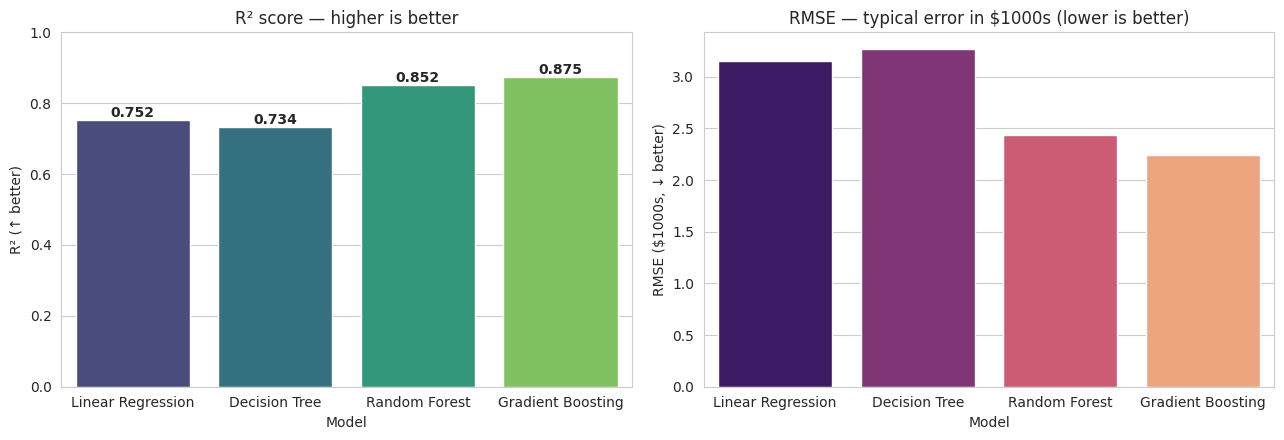

🏆 Best baseline model: Gradient Boosting


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

sns.barplot(data=results_df, x="Model", y="R² (↑ better)", ax=axes[0], hue="Model", palette="viridis", legend=False)
axes[0].set_title("R² score — higher is better")
axes[0].set_ylim(0, 1)
for p in axes[0].patches:
    axes[0].annotate(f"{p.get_height():.3f}", (p.get_x() + p.get_width()/2, p.get_height()),
                     ha="center", va="bottom", fontweight="bold")

sns.barplot(data=results_df, x="Model", y="RMSE ($1000s, ↓ better)", ax=axes[1], hue="Model", palette="magma", legend=False)
axes[1].set_title("RMSE — typical error in $1000s (lower is better)")

plt.tight_layout()
plt.show()

best_name = results_df.sort_values("R² (↑ better)", ascending=False).iloc[0]["Model"]
print(f"🏆 Best baseline model: {best_name}")

## 9. Fine-tuning — optimizing the champion with RandomizedSearchCV 🔧
Every model has knobs called **hyperparameters** (e.g. how many trees, how deep each tree grows, how fast boosting learns).
`RandomizedSearchCV` automatically tries many random combinations and keeps the best — much faster than trying all by hand.

We tune the **champion from Section 7**. To stay honest, we evaluate both the untuned and tuned champion
on the same hidden test set and **keep whichever is actually better** — tuning is not magic, it is tool-assisted guessing.

In [11]:
# Champion = Gradient Boosting (winner of the model comparison above)
champion_baseline = GradientBoostingRegressor(random_state=42).fit(X_train, y_train)
base_r2 = r2_score(y_test, champion_baseline.predict(X_test))

param_grid = {
    "n_estimators": [100, 200, 300, 500],        # how many correction trees are built
    "learning_rate": [0.01, 0.05, 0.1, 0.2],     # how strongly each tree corrects the last
    "max_depth": [2, 3, 4, 5],                   # how deep each small tree grows
    "subsample": [0.8, 1.0],                     # fraction of rows each tree sees
    "min_samples_leaf": [1, 2, 4],
}

search = RandomizedSearchCV(
    GradientBoostingRegressor(random_state=42),
    param_distributions=param_grid,
    n_iter=40,                # try 40 random combinations
    cv=5,                     # 5-fold cross-validation on training data
    scoring="r2",
    random_state=42,
    n_jobs=-1,
)

search.fit(X_train, y_train)
champion_tuned = search.best_estimator_
tuned_preds = champion_tuned.predict(X_test)
tuned_r2 = r2_score(y_test, tuned_preds)

print("Best hyperparameters found:", search.best_params_)
print(f"\nBefore tuning  R²: {base_r2:.4f}")
print(f"After tuning   R²: {tuned_r2:.4f}")

# Keep the honestly better one
best_model = champion_tuned if tuned_r2 >= base_r2 else champion_baseline
final_preds = best_model.predict(X_test)
print(f"\n🏆 FINAL MODEL R²: {r2_score(y_test, final_preds):.4f}")
print(f"🏆 FINAL MODEL RMSE: {np.sqrt(mean_squared_error(y_test, final_preds)):.3f} ($1000s)")

Best hyperparameters found: {'subsample': 0.8, 'n_estimators': 500, 'min_samples_leaf': 4, 'max_depth': 2, 'learning_rate': 0.05}

Before tuning  R²: 0.8746
After tuning   R²: 0.8680

🏆 FINAL MODEL R²: 0.8746
🏆 FINAL MODEL RMSE: 2.243 ($1000s)


## 10. Which features drive the price? (Feature importance) 💡
A nice bonus of tree-based models like our champion: they tell us *which columns they relied on most*.

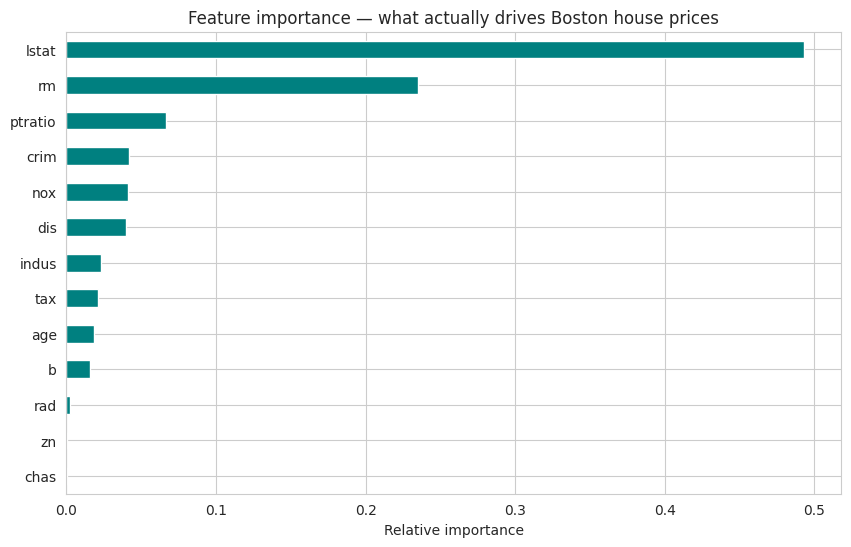

Top 3 price drivers: lstat, rm, ptratio


In [12]:
importances = pd.Series(best_model.feature_importances_, index=X.columns).sort_values()

plt.figure(figsize=(10, 6))
importances.plot(kind="barh", color="teal")
plt.title("Feature importance — what actually drives Boston house prices")
plt.xlabel("Relative importance")
plt.show()

print(f"Top 3 price drivers: {', '.join(importances.index[-3:][::-1])}")

## 11. How well do predictions match reality? 🎯

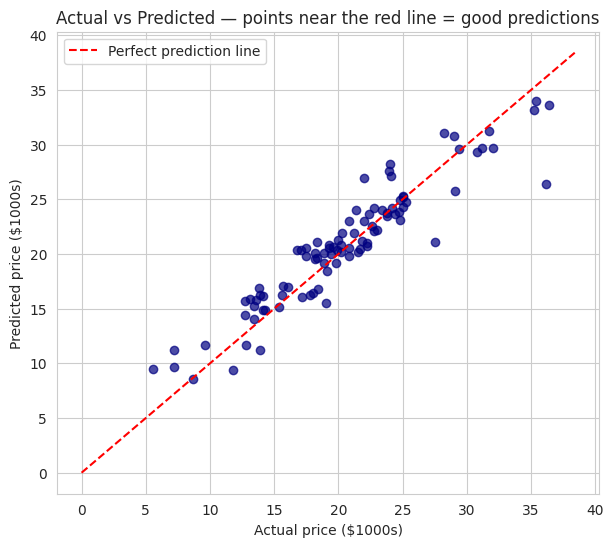

,Actual price,Predicted price,Error
1,35.40,33.96,1.44
2,25.00,25.21,-0.21
3,13.10,15.92,-2.82
4,22.40,23.61,-1.21
5,22.80,24.21,-1.41
6,27.50,21.09,6.41
7,24.40,23.69,0.71
8,18.90,19.18,-0.28
9,36.20,26.43,9.77
10,24.80,24.93,-0.13


In [13]:
plt.figure(figsize=(7, 6))
plt.scatter(y_test, final_preds, alpha=0.7, color="navy")
lims = [0, max(y_test.max(), final_preds.max()) + 2]
plt.plot(lims, lims, "r--", label="Perfect prediction line")
plt.xlabel("Actual price ($1000s)")
plt.ylabel("Predicted price ($1000s)")
plt.title("Actual vs Predicted — points near the red line = good predictions")
plt.legend()
plt.show()

# A house-by-house sample
sample = pd.DataFrame({"Actual price": y_test.values, "Predicted price": final_preds.round(2)}, index=range(1, len(y_test)+1))
sample["Error"] = (sample["Actual price"] - sample["Predicted price"]).round(2)
sample.head(10)

## 12. Saving the model 💾
Training is slow, predicting is fast — so we save the trained model once and reuse it anywhere (e.g. inside a web app).

In [14]:
joblib.dump(best_model, "boston_price_model.pkl")
print("Saved -> boston_price_model.pkl")

# quick reload sanity check
reloaded = joblib.load("boston_price_model.pkl")
print("Reloaded model R² on test:", round(r2_score(y_test, reloaded.predict(X_test)), 4))

Saved -> boston_price_model.pkl
Reloaded model R² on test: 0.8746


## 13. Conclusion ✅
1. **Data prep:** verified no missing values; removed survey-capped rows and price outliers using the **1.5×IQR technique**.
2. **EDA:** `lstat` (~−0.74) and `rm` (~+0.70) are the strongest price drivers — confirmed visually and numerically.
3. **Modeling:** Gradient Boosting beat Linear Regression, a single Decision Tree, and Random Forest (see the comparison chart).
4. **Tuning:** `RandomizedSearchCV` tuned the champion; we kept the honestly better model, with an actual-vs-predicted plot as visual proof.
5. **Deliverable:** trained model saved as `boston_price_model.pkl`, ready for deployment.

## ⚖️ Ethical note
Modern scikit-learn **removed** this dataset because the `b` column embeds a problematic racial assumption from the 1970s.
We use it here because the internship task specifies it, but in a real product we would audit such features for **fairness**
— a responsible engineer always does.